# Unsupervised learning

Unsupervised learning in machine learning is the task of finding patterns or structure in data without using labeled outputs. Unlike classification and regression, where we have both features (`X`) and target values (`y`), in unsupervised learning we only have `X`.

The goal is to discover hidden relationships or groupings within the data, such as finding similar customers based on their behavior, or grouping similar images together.

You have already learned supervised learning methods (classification and regression), where the model learns from known labels (`y`). Now, we will explore unsupervised learning, where the model must make sense of the data on its own, without being told what the correct answers are.

As discussed in Chapter 1 of the course textbook, unsupervised learning includes several approaches such as clustering, anomaly detection, and dimensionality reduction. In this notebook, we will focus on clustering, which aims to group similar data points together based on their characteristics.

## 1. Your first clustering model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the dataset
from sklearn.datasets import fetch_california_housing
X, _ = fetch_california_housing(as_frame=True, return_X_y=True)

In [3]:
X.shape

(20640, 8)

In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


We will cluster the data using only two features, Latitude and Longitude, so that the clusters can be visualized easily. Later, we will explore techniques for visualizing clusters in higher-dimensional datasets.

In [5]:
X = X[['Latitude', 'Longitude']]
X.head()

,Latitude,Longitude
0,37.88,-122.23
1,37.86,-122.22
2,37.85,-122.24
3,37.85,-122.25
4,37.85,-122.25


let's first plot X to see if it looks like California.

Text(0, 0.5, 'Latitude')

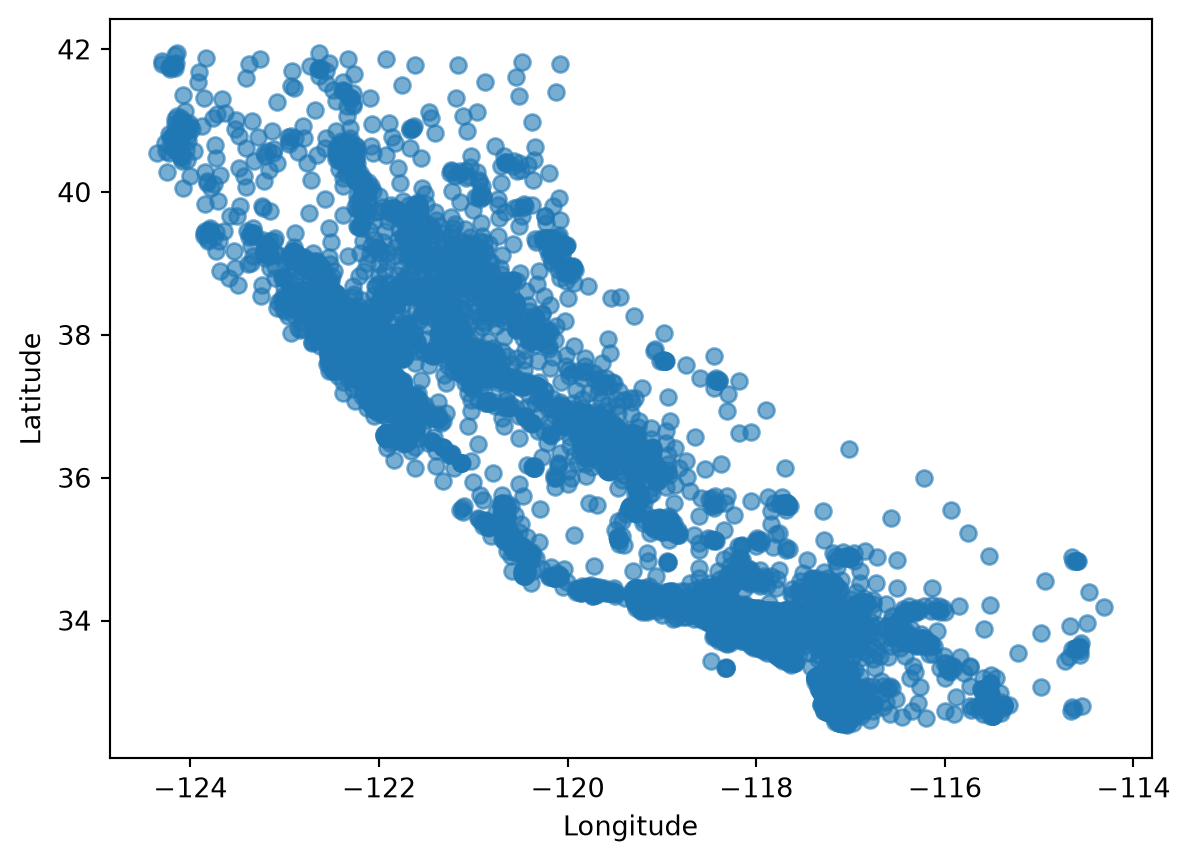

In [6]:
plt.scatter(X['Longitude'], X['Latitude'], alpha=0.6) # alpha sets transparency
plt.xlabel('Longitude')
plt.ylabel('Latitude')

It looks like California indeed

<img src="https://upload.wikimedia.org/wikipedia/commons/5/55/California_Topography_and_Geomorphic.gif" width="50%">

Now we can fit a clustering model to our data `X` and visualize the results on our plot using different colors for each cluster.

There are many clustering algorithms available. A common starting point is **K-Means**, but here we’ll use **HDBSCAN** instead. HDBSCAN has two important advantages that make it easier to work with, especially when exploring new datasets:

* **No need to choose the number of clusters.**
  K-Means requires you to decide in advance how many clusters you want. HDBSCAN automatically finds a suitable number of clusters based on the data.

* **It can detect noise points.**
  HDBSCAN can mark data points that don’t clearly belong to any cluster as *noise* (labeled as `-1`). K-Means, on the other hand, forces every point into a cluster, even if it doesn’t fit well.

In [7]:
# The default value of min_cluster_size is 5.
# Since the California housing dataset has around 20,000 data points,
# this would create too many small clusters.
# To avoid that, we increase min_cluster_size to form larger, more meaningful clusters.
from sklearn.cluster import HDBSCAN
hdb = HDBSCAN(min_cluster_size=500)
hdb.fit(X)

/Users/alican/Documents/ML projects/BUas/public_courses/ml-book/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,"min_cluster_size min_cluster_size: int, default=5The minimum number of samples in a group for that group to beconsidered a cluster; groupings smaller than this size will be leftas noise.",500
,"min_samples min_samples: int, default=NoneThe parameter `k` used to calculate the distance between a point`x_p` and its k-th nearest neighbor.When `None`, defaults to `min_cluster_size`.",None
,"cluster_selection_epsilon cluster_selection_epsilon: float, default=0.0A distance threshold. Clusters below this value will be merged.See [5]_ for more information.",0.0
,"max_cluster_size max_cluster_size: int, default=NoneA limit to the size of clusters returned by the `""eom""` clusterselection algorithm. There is no limit when `max_cluster_size=None`.Has no effect if `cluster_selection_method=""leaf""`.",None
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array.- If metric is a string or callable, it must be one of the options allowed by :func:`~sklearn.metrics.pairwise_distances` for its metric parameter.- If metric is ""precomputed"", X is assumed to be a distance matrix and must be square.",'euclidean'
,"metric_params metric_params: dict, default=NoneArguments passed to the distance metric.",None
,"alpha alpha: float, default=1.0A distance scaling parameter as used in robust single linkage.See [3]_ for more information.",1.0
,"algorithm algorithm: {""auto"", ""brute"", ""kd_tree"", ""ball_tree""}, default=""auto""Exactly which algorithm to use for computing core distances; By defaultthis is set to `""auto""` which attempts to use a:class:`~sklearn.neighbors.KDTree` tree if possible, otherwise it usesa :class:`~sklearn.neighbors.BallTree` tree. Both `""kd_tree""` and`""ball_tree""` algorithms use the:class:`~sklearn.neighbors.NearestNeighbors` estimator.If the `X` passed during `fit` is sparse or `metric` is invalid forboth :class:`~sklearn.neighbors.KDTree` and:class:`~sklearn.neighbors.BallTree`, then it resolves to use the`""brute""` algorithm.",'auto'
,"leaf_size leaf_size: int, default=40Leaf size for trees responsible for fast nearest neighbour queries whena KDTree or a BallTree are used as core-distance algorithms. A largedataset size and small `leaf_size` may induce excessive memory usage.If you are running out of memory consider increasing the `leaf_size`parameter. Ignored for `algorithm=""brute""`.",40
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel to calculate distances.`None` means 1 unless in a :obj:`joblib.parallel_backend` context.`-1` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"cluster_selection_method cluster_selection_method: {""eom"", ""leaf""}, default=""eom""The method used to select clusters from the condensed tree. Thestandard approach for HDBSCAN* is to use an Excess of Mass (`""eom""`)algorithm to find the most persistent clusters. Alternatively you caninstead select the clusters at the leaves of the tree -- this providesthe most fine grained and homogeneous clusters.",'eom'


In [8]:
# The labels_ attribute contains the cluster label 
# assigned to each data point after fitting the model.
hdb.labels_

array([ 3,  3,  3, ..., -1, -1, -1], shape=(20640,))

In [9]:
# Shows all unique cluster labels found by the model
# including -1 for noise points
unique_labels = np.unique(hdb.labels_)
unique_labels

array([-1,  0,  1,  2,  3,  4])

Let’s re-plot the scatter plot, but this time, giving one color per cluster so points in the same cluster share a color.

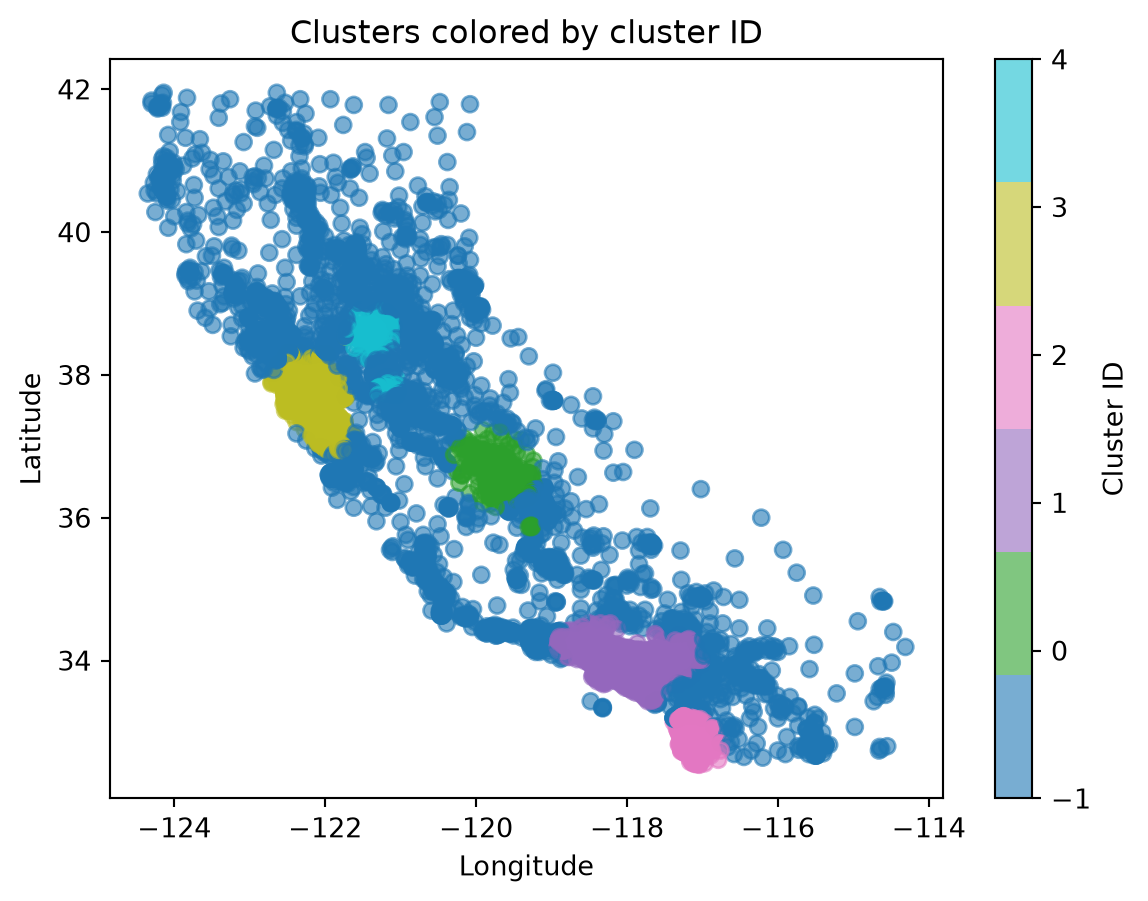

In [10]:
# same scatter plot as before
# but now each cluster is shown in a different color using the cluster labels from hdb.labels_

# create a colormap per cluster ID
from matplotlib.colors import ListedColormap
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))  # pick only needed colors
cmap = ListedColormap(colors)

plt.scatter(X['Longitude'], X['Latitude'], c=hdb.labels_, cmap=cmap, alpha=0.6) # add color map parameters
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Clusters colored by cluster ID")
plt.colorbar(label="Cluster ID")

We can see some clusters, but the noise datapoints (-1) make it hard to see clusters. Let’s separate the noise from the clusters and hide the noise points in the next plot for better visibility.

In [11]:
# select only the points labeled as noise (-1)
X_noise = X[hdb.labels_ == -1]

# select only the points that belong to a cluster (exclude noise)
X_clusters = X[hdb.labels_ != -1]

# get the cluster labels for the non-noise points
labels_without_noise = hdb.labels_[hdb.labels_ != -1]
unique_labels_without_noise = np.unique(labels_without_noise)

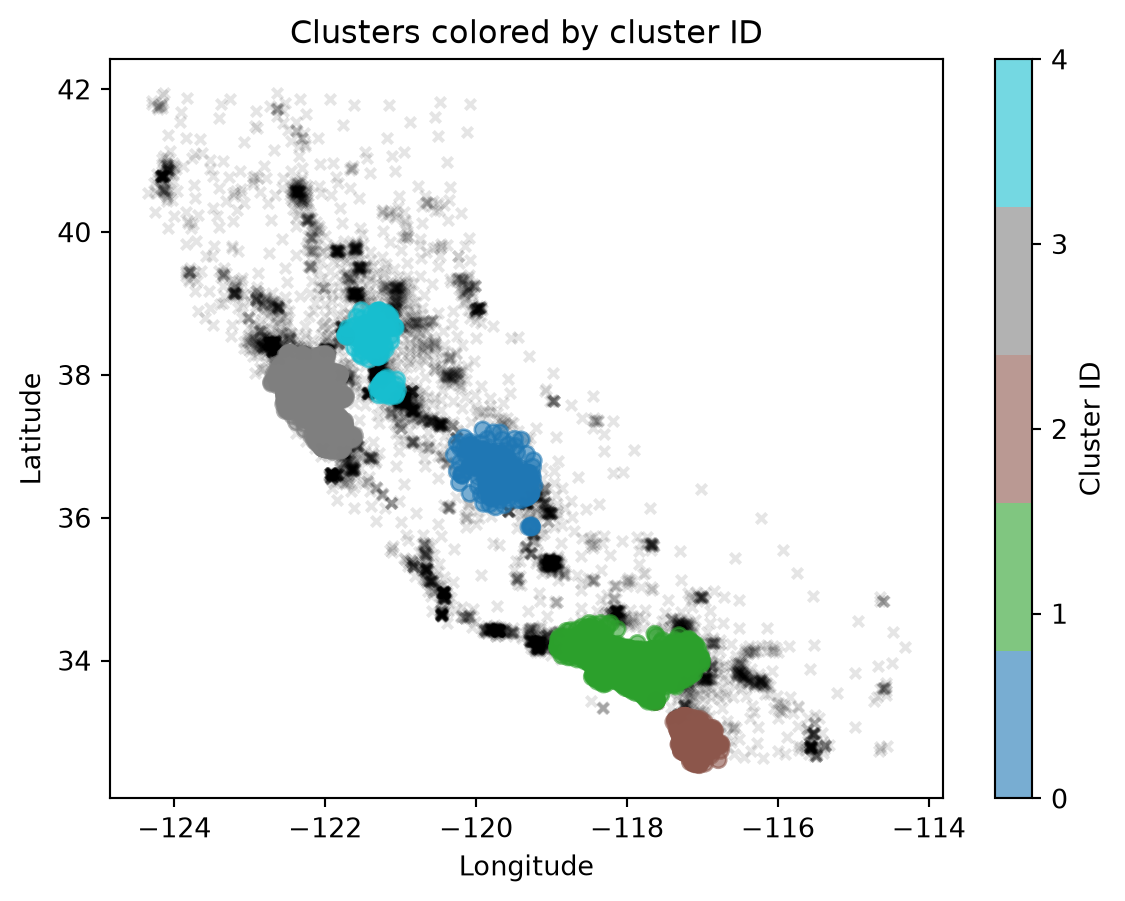

In [12]:
from matplotlib.colors import ListedColormap
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_without_noise)))  # pick only needed colors
cmap = ListedColormap(colors)

plt.scatter(X_noise['Longitude'], X_noise['Latitude'], alpha=0.1, color='black', marker='x', s=15) # make noise points, black, marker x, more transparent, smaller size
plt.scatter(X_clusters['Longitude'], X_clusters['Latitude'], c=labels_without_noise, cmap=cmap, alpha=0.6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Clusters colored by cluster ID")

# create a colorbar with integer ticks only
cbar = plt.colorbar(label="Cluster ID")
cbar.set_ticks(unique_labels_without_noise)  # show only integer cluster IDs

Interpreting clusters usually requires domain knowledge and a solid understanding of the dataset. In this case, our common sense tells us that many nearby houses represent densely populated regions, which likely correspond to cities. By comparing the plot with a map of California, we can roughly identify these clusters as areas such as Los Angeles, San Diego, and other major urban centers.

<img src="https://upload.wikimedia.org/wikipedia/commons/5/55/California_Topography_and_Geomorphic.gif" width="50%">

## 2. Exercise

<mark>YOUR TURN</mark>

Pick a dataset and select any two features. Fit a clustering model, then plot feature 1 vs. feature 2, coloring the data points by their cluster labels.

Try to interpret what you see, are there clear groups or mostly overlapping points? The results will vary depending on your choice of model and features. Some combinations will show distinct clusters, while others may look messy or random.

Experiment with different datasets and feature pairs until you find a case where the clusters stand out clearly.

In [13]:
# YOUR CODE HERE